In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("digital_payment_behavior_clustering_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5000 non-null   object 
 1   city                       5000 non-null   object 
 2   device_type                5000 non-null   object 
 3   kyc_level                  5000 non-null   object 
 4   account_age_months         5000 non-null   int64  
 5   account_age_band           5000 non-null   object 
 6   active_days_per_month      5000 non-null   int64  
 7   transactions_per_day       5000 non-null   float64
 8   monthly_transaction_count  5000 non-null   int64  
 9   avg_transaction_amount     5000 non-null   float64
 10  max_transaction_amount     5000 non-null   float64
 11  total_monthly_spend        5000 non-null   float64
 12  merchant_txn_ratio         5000 non-null   float64
 13  peer_txn_ratio             5000 non-null   float

In [4]:
df["user_id"].nunique()

5000

In [5]:
df.isnull().sum()

user_id                      0
city                         0
device_type                  0
kyc_level                    0
account_age_months           0
account_age_band             0
active_days_per_month        0
transactions_per_day         0
monthly_transaction_count    0
avg_transaction_amount       0
max_transaction_amount       0
total_monthly_spend          0
merchant_txn_ratio           0
peer_txn_ratio               0
merchant_count_month         0
peer_count_month             0
failed_transactions          0
failed_txn_ratio             0
refund_requests              0
refund_ratio                 0
night_txn_ratio              0
weekend_txn_ratio            0
session_count                0
app_open_frequency           0
avg_session_duration_min     0
avg_gap_between_txn_hours    0
spend_volatility             0
avg_balance_before_txn       0
cashback_usage_ratio         0
suspicious_activity_score    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["user_id"].unique()

array(['UPI00001', 'UPI00002', 'UPI00003', ..., 'UPI04998', 'UPI04999',
       'UPI05000'], shape=(5000,), dtype=object)

In [25]:
df["city"].value_counts()

city
Pune         643
Hyderabad    636
Delhi        632
Bengaluru    632
Mumbai       627
Ahmedabad    621
Chennai      606
Kolkata      603
Name: count, dtype: int64

In [9]:
df["device_type"].value_counts()

device_type
Android    3871
iOS        1129
Name: count, dtype: int64

In [26]:
df["kyc_level"].value_counts()

kyc_level
Full       2879
Minimum    1423
Premium     698
Name: count, dtype: int64

In [27]:
df["account_age_band"].value_counts()

account_age_band
1-2y     2241
2y+      1201
6-12m     882
0-6m      676
Name: count, dtype: int64

In [12]:
df["account_age_months"].min()

1

In [13]:
df["account_age_months"].max()

58

In [14]:
df["account_age_months"].mean()

np.float64(17.557)

In [28]:
df.groupby("kyc_level")["monthly_transaction_count"].mean()

kyc_level
Full       86.377562
Minimum    86.205903
Premium    86.597421
Name: monthly_transaction_count, dtype: float64

In [29]:
df["active_days_per_month"].mean()

np.float64(17.1322)

In [16]:
df["monthly_transaction_count"].value_counts()

monthly_transaction_count
1      276
4       63
3       63
2       60
5       54
      ... 
320      1
440      1
284      1
240      1
296      1
Name: count, Length: 315, dtype: int64

In [32]:
df.sort_values(["monthly_transaction_count","active_days_per_month"],ascending=[False,True])[["user_id","monthly_transaction_count","active_days_per_month"]].head(10)

,user_id,monthly_transaction_count,active_days_per_month
2656,UPI02657,440,25
3394,UPI03395,411,23
2099,UPI02100,403,25
4907,UPI04908,401,30
3350,UPI03351,385,28
1516,UPI01517,364,31
289,UPI00290,363,29
2083,UPI02084,343,23
1654,UPI01655,343,25
1557,UPI01558,341,30


In [34]:
df.groupby("account_age_band")["avg_gap_between_txn_hours"].mean()

account_age_band
0-6m     35.801627
1-2y     38.799241
2y+      34.940325
6-12m    41.961701
Name: avg_gap_between_txn_hours, dtype: float64

In [35]:
df.groupby("account_age_band")["avg_gap_between_txn_hours"].mean()

account_age_band
0-6m     35.801627
1-2y     38.799241
2y+      34.940325
6-12m    41.961701
Name: avg_gap_between_txn_hours, dtype: float64

In [17]:
df.groupby(["monthly_transaction_count"])["user_id"].sum().max()

'UPI04976'

In [36]:
df.groupby("account_age_band")["monthly_transaction_count"].mean()

account_age_band
0-6m     89.343195
1-2y     86.827309
2y+      86.867610
6-12m    82.191610
Name: monthly_transaction_count, dtype: float64

In [38]:
df["avg_transaction_amount"].mean()
df["avg_transaction_amount"].min()
df["avg_transaction_amount"].max()

7057.3

In [39]:
df["total_monthly_spend"].value_counts()

total_monthly_spend
100.00       29
900000.00     3
87460.70      2
99771.89      1
41002.15      1
             ..
124832.02     1
148824.38     1
30610.27      1
58604.20      1
22420.53      1
Name: count, Length: 4969, dtype: int64

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

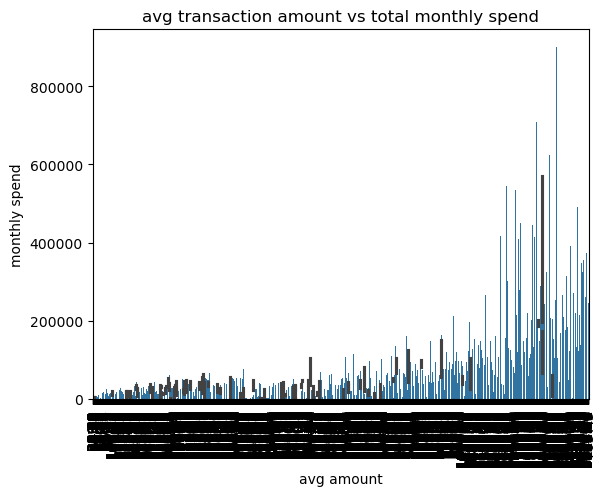

In [40]:
sns.barplot(x=df["avg_transaction_amount"], y=df["total_monthly_spend"])
plt.title("avg transaction amount vs total monthly spend")
plt.xlabel("avg amount")
plt.ylabel("monthly spend")
plt.xticks(rotation=90)
plt.show()

In [41]:
df.sort_values(["monthly_transaction_count","avg_transaction_amount"],ascending=[False,True])[["user_id","monthly_transaction_count","avg_transaction_amount"]].head(10)

,user_id,monthly_transaction_count,avg_transaction_amount
2656,UPI02657,440,1462.45
3394,UPI03395,411,485.10
2099,UPI02100,403,4166.72
4907,UPI04908,401,3396.53
3350,UPI03351,385,244.73
1516,UPI01517,364,177.51
289,UPI00290,363,2692.39
2083,UPI02084,343,40.00
1654,UPI01655,343,154.30
1557,UPI01558,341,174.29


In [42]:
df.sort_values(["monthly_transaction_count","avg_transaction_amount"],ascending=[True,False])[["user_id","monthly_transaction_count","avg_transaction_amount"]].head(10)

,user_id,monthly_transaction_count,avg_transaction_amount
4916,UPI04917,1,4133.28
2758,UPI02759,1,3699.61
2486,UPI02487,1,2999.04
359,UPI00360,1,2893.08
642,UPI00643,1,2427.31
4291,UPI04292,1,2057.23
256,UPI00257,1,1971.51
1591,UPI01592,1,1905.09
4634,UPI04635,1,1859.54
3301,UPI03302,1,1800.47


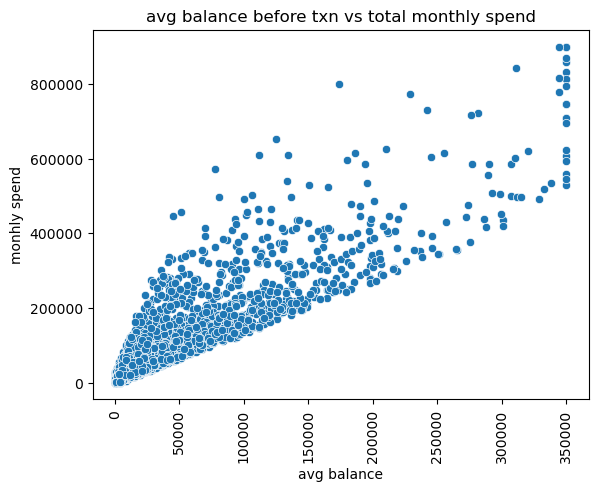

In [61]:
sns.scatterplot(x=df["avg_balance_before_txn"], y=df["total_monthly_spend"])
plt.title("avg balance before txn vs total monthly spend")
plt.xlabel("avg balance")
plt.ylabel("monhly spend")
plt.xticks(rotation=90)
plt.show()

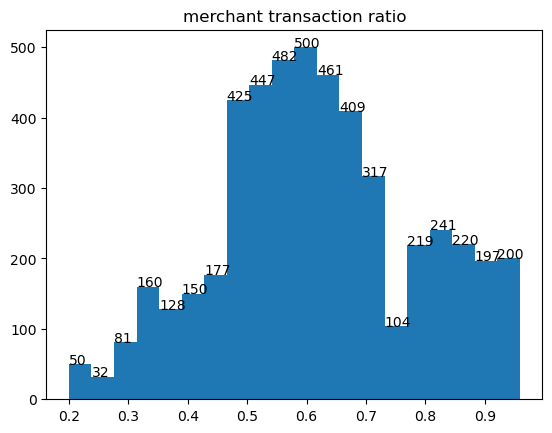

In [60]:
count, bins, bars = plt.hist(df["merchant_txn_ratio"], bins=20)
for i in range(len(count)):
    plt.text(bins[i], count[i], int(count[i]))
plt.title("merchant transaction ratio")
plt.show()

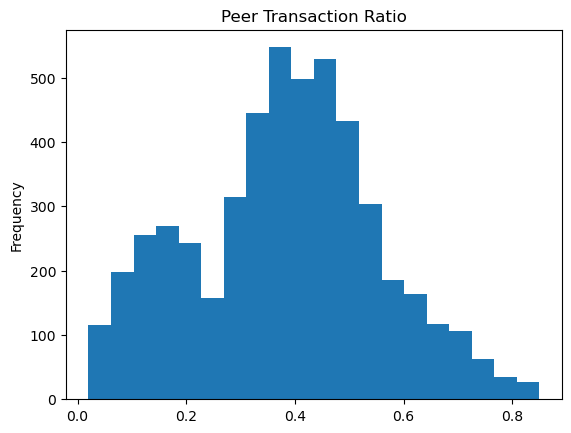

In [45]:
df["peer_txn_ratio"].plot(kind="hist", bins=20)
plt.title("Peer Transaction Ratio")
plt.show()

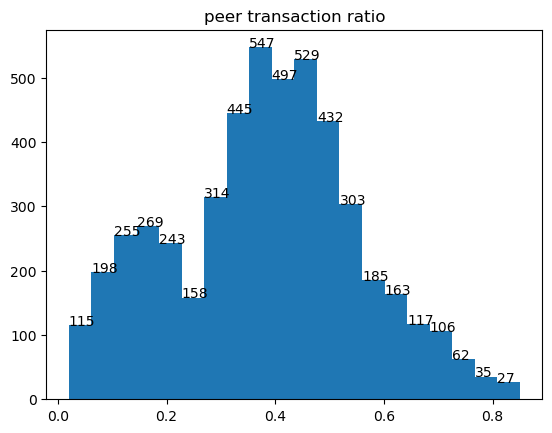

In [63]:
count, bins, bars = plt.hist(df["peer_txn_ratio"], bins=20)
for i in range(len(count)):
    plt.text(bins[i], count[i], int(count[i]))
plt.title("peer transaction ratio")
plt.show()

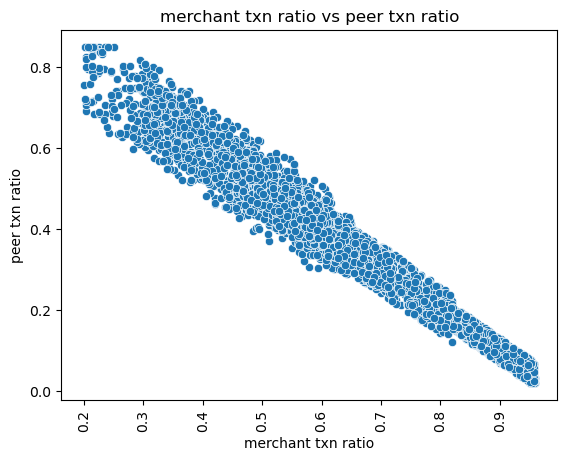

In [52]:
sns.scatterplot(x=df["merchant_txn_ratio"], y=df["peer_txn_ratio"])
plt.title("merchant txn ratio vs peer txn ratio")
plt.xlabel("merchant txn ratio")
plt.ylabel("peer txn ratio")
plt.xticks(rotation=90)
plt.show()

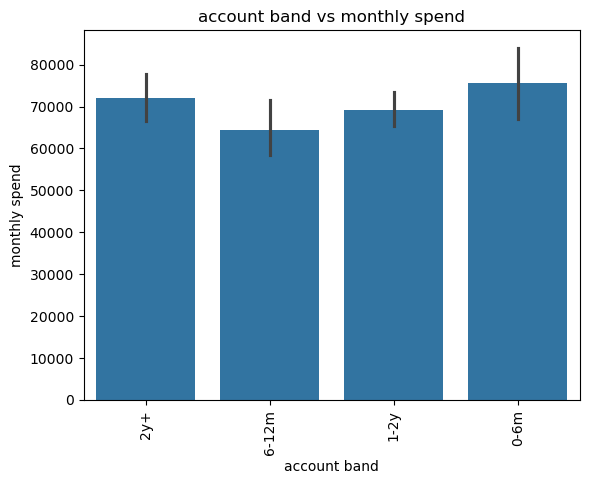

In [54]:
sns.barplot(x=df["account_age_band"], y=df["total_monthly_spend"])
plt.title("account band vs monthly spend")
plt.xlabel("account band")
plt.ylabel("monthly spend")
plt.xticks(rotation=90)
plt.show()

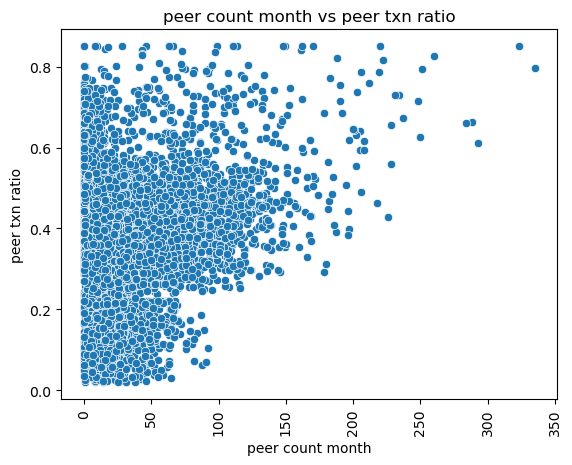

In [58]:
sns.scatterplot(x=df["peer_count_month"], y=df["peer_txn_ratio"])
plt.title("peer count month vs peer txn ratio")
plt.xlabel("peer count month")
plt.ylabel("peer txn ratio")
plt.xticks(rotation=90)
plt.show()